## 1. Configuração do Ambiente
Nesta etapa, configuramos o caminho raiz do projeto e o adicionamos ao `sys.path`. Este passo é essencial para garantir que o Python consiga localizar e importar nossos módulos customizados (pasta `src`) de forma consistente, independentemente de onde o notebook está sendo executado.

In [1]:
from pathlib import Path
import sys

# Define a raiz do projeto assumindo que o notebook está em notebooks/river_level/
RAIZ_PROJETO = Path.cwd().resolve().parents[1]

if str(RAIZ_PROJETO) not in sys.path:
    sys.path.insert(0, str(RAIZ_PROJETO))

print("Diretório atual:", Path.cwd())
print("Raiz do projeto:", RAIZ_PROJETO)
print("Primeiro item do sys.path:", sys.path[0])
print("Pasta src existe?", (RAIZ_PROJETO / "src").exists())

Diretório atual: c:\Users\guerr\OneDrive\Documents\VSCode\FrameWork_MLOps_Unificado\notebooks\river_level
Raiz do projeto: C:\Users\guerr\OneDrive\Documents\VSCode\FrameWork_MLOps_Unificado
Primeiro item do sys.path: C:\Users\guerr\OneDrive\Documents\VSCode\FrameWork_MLOps_Unificado
Pasta src existe? True


## 2. Importação de Módulos e Caminhos de Dados
Aqui, importamos as funções modulares de ingestão e pré-processamento responsáveis por encapsular a lógica de tratamento (ETL). Também definimos e validamos o caminho absoluto para o arquivo bruto de Excel, garantindo que o dado de origem esteja acessível antes de iniciarmos o processamento.

In [2]:
from src.utils.io_utils import ler_yaml
from src.river_level.ingestao import consolidar_base_nivel_precipitacao
from src.river_level.preprocessamento import preparar_base_modelagem

caminho_yaml = RAIZ_PROJETO / "experiments/river_level/baseline_lstm.yaml"
config = ler_yaml(caminho_yaml)

caminho_arquivo = RAIZ_PROJETO / config["dados"]["caminho_arquivo"]

print("Arquivo existe?", caminho_arquivo.exists())
print("Caminho completo:", caminho_arquivo)
print("Arquivo de configuração:", caminho_yaml)

Arquivo existe? True
Caminho completo: C:\Users\guerr\OneDrive\Documents\VSCode\FrameWork_MLOps_Unificado\data\raw\river_level\2021_NivelRD PIMS_Felipe_V01.xlsm
Arquivo de configuração: C:\Users\guerr\OneDrive\Documents\VSCode\FrameWork_MLOps_Unificado\experiments\river_level\baseline_lstm.yaml


## 3. Ingestão e Pré-processamento dos Dados
Lemos as planilhas de nível e clima a partir da configuração oficial do experimento. Em seguida, consolidamos a precipitação média das estações de interesse e preparamos a base para modelagem, com filtro temporal, tratamento inicial de valores faltantes e ajuste do evento anômalo de novembro de 2015.

In [3]:
dados_cfg = config["dados"]
preprocessamento_cfg = config["preprocessamento"]

planilha_nivel_cfg = dados_cfg["planilha_nivel"]
planilha_clima_cfg = dados_cfg["planilha_clima"]
agregacao_cfg = dados_cfg["agregacao_precipitacao"]

df_base = consolidar_base_nivel_precipitacao(
    caminho_arquivo=caminho_arquivo,
    nome_planilha_nivel=planilha_nivel_cfg["nome"],
    nome_planilha_clima=planilha_clima_cfg["nome"],
    estacoes_interesse=agregacao_cfg["estacoes_interesse"],
    skiprows_nivel=planilha_nivel_cfg["skiprows"],
    skiprows_clima=planilha_clima_cfg["skiprows"],
    usecols_nivel=planilha_nivel_cfg["usecols"],
    usecols_clima=planilha_clima_cfg["usecols"],
    coluna_data=planilha_nivel_cfg["coluna_data"],
    coluna_nivel=planilha_nivel_cfg["coluna_nivel"],
    coluna_estacao=planilha_clima_cfg["coluna_estacao"],
    coluna_precipitacao=planilha_clima_cfg["coluna_precipitacao"],
    coluna_radiacao=planilha_clima_cfg["coluna_radiacao"],
    nome_coluna_precipitacao_media=agregacao_cfg["nome_coluna_saida"],
)

print(df_base.head())
print(df_base.tail())
print(df_base.isna().sum())

df_modelagem = preparar_base_modelagem(
    df=df_base,
    data_inicio=preprocessamento_cfg["data_inicio"],
    data_fim=preprocessamento_cfg["data_fim"],
    tratar_evento_2015=preprocessamento_cfg["tratar_evento_2015"],
)

print(df_modelagem.head())
print(df_modelagem.tail())
print(df_modelagem.isna().sum())

c:\Users\guerr\.conda\envs\mlops_river_level\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)
C:\Users\guerr\OneDrive\Documents\VSCode\FrameWork_MLOps_Unificado\src\utils\io_utils.py:111: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  datas_convertidas.loc[mascara_invalidas] = pd.to_datetime(


            Nivel  Precip_Media_Estacoes
Data                                    
2000-01-01   3.22               8.076842
2000-01-02   3.25               7.109579
2000-01-03   3.49               8.611470
2000-01-04   3.95               5.346667
2000-01-05   3.94               0.333333
            Nivel  Precip_Media_Estacoes
Data                                    
2026-09-10    NaN                    NaN
2026-09-11    NaN                    NaN
2026-09-12    NaN                    NaN
2026-09-13    NaN                    NaN
2026-09-14    NaN                    NaN
Nivel                    202
Precip_Media_Estacoes    186
dtype: int64
            Nivel  Precip_Media_Estacoes
Data                                    
2005-01-01   4.16                 0.1905
2005-01-02   3.99                12.3170
2005-01-03   4.06                19.7475
2005-01-04   3.76                 1.3970
2005-01-05   3.61                11.1765
               Nivel  Precip_Media_Estacoes
Data                    

## 4. Exportação da Base Processada
Com a base preparada para modelagem após o tratamento inicial dos dados, salvamos o DataFrame resultante (`df_modelagem`) na camada de dados processados (`data/processed`). Isso cria um ponto de controle para que as etapas subsequentes consumam diretamente uma base consolidada e validada.

In [ ]:
from pathlib import Path

pasta_saida = RAIZ_PROJETO / "data/processed/river_level"
pasta_saida.mkdir(parents=True, exist_ok=True)

caminho_saida_csv = pasta_saida / "dataset_base_modelagem.csv"

df_modelagem.to_csv(
    caminho_saida_csv,
    index=True,
    index_label="Data",
    encoding="utf-8-sig",
)

print("Arquivo salvo em:", caminho_saida_csv)
print("Existe?", caminho_saida_csv.exists())

Arquivo salvo em: C:\Users\guerr\OneDrive\Documents\VSCode\FrameWork_MLOps_Unificado\data\processed\river_level\dataset_base_modelagem.csv
Existe? True


## 5. Visualização e Validação da Série Temporal
Nesta seção exploratória final, plotamos as séries de Nível do Rio e Precipitação no mesmo gráfico, utilizando eixos paralelos e o eixo da precipitação invertido. Essa visualização auxilia na avaliação da coerência temporal entre a chuva observada e a resposta do nível do rio ao longo da série.

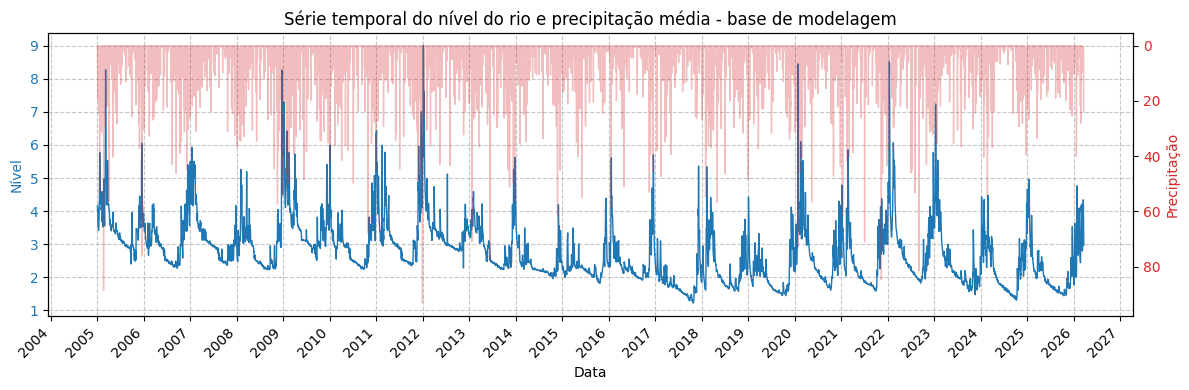

In [5]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

nome_coluna_precipitacao = agregacao_cfg["nome_coluna_saida"]

fig, ax1 = plt.subplots(figsize=(12, 4))

# Nível do Rio (já estava como linha)
ax1.plot(df_modelagem.index, df_modelagem["Nivel"], color="tab:blue", linewidth=1.0)
ax1.set_xlabel("Data")
ax1.set_ylabel("Nível", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True, linestyle="--", alpha=0.7)

# Eixo secundário para a precipitação
ax2 = ax1.twinx()

# Precipitação alterada para linha (.plot em vez de .bar)
ax2.plot(
    df_modelagem.index,
    df_modelagem[nome_coluna_precipitacao],
    color="tab:red",
    alpha=0.30,
    linewidth=1.0  # Ajuste a espessura da linha se achar necessário
)
ax2.set_ylabel("Precipitação", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")
ax2.invert_yaxis()

# Formatação do eixo X
ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha="right")

plt.title("Série temporal do nível do rio e precipitação média - base de modelagem")
fig.tight_layout()
plt.show()